In [16]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Reading the Image using Pillow
# ==============================


In [17]:
# Open image
img = Image.open('pexels-alexravvas-26611787.jpg')

# Convert to grayscale
image_gray = img.convert('L')

# Convert to RGB
image_rgb = img.convert('RGB')

# Convert to numpy arrays
image = np.array(image_gray)
image2 = np.array(image_rgb)



# Display original grayscale image

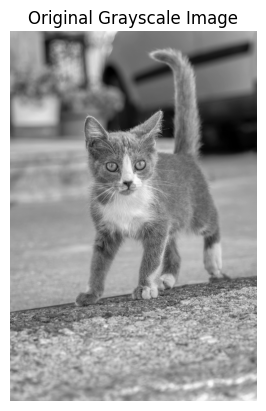

In [18]:

plt.imshow(image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()



# ==============================
# Display using Matplotlib
# ==============================


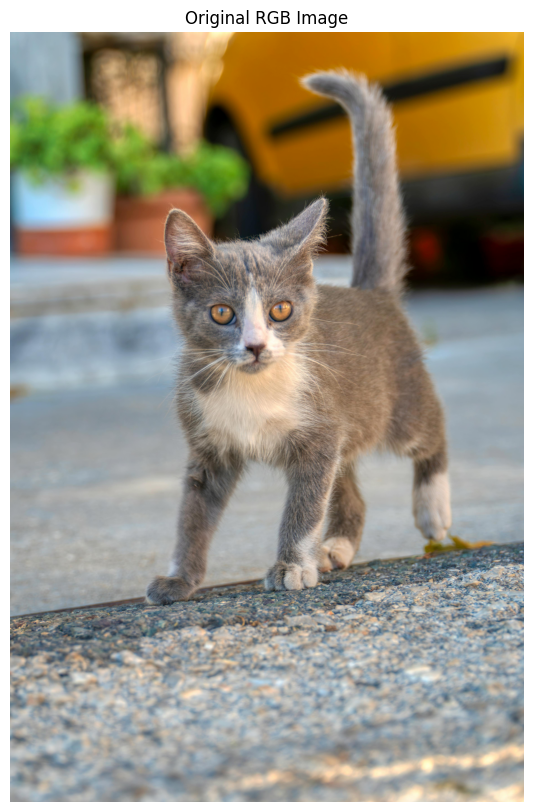

In [6]:

plt.figure(figsize=(10, 10))
plt.imshow(image2)
plt.title('Original RGB Image')
plt.axis('off')
plt.show()



# ==============================
# Shape and Type
# ==============================


In [7]:

print(f"Shape of the Image: {image.shape}")
print(f"Type of the Image: {type(image)}")



Shape of the Image: (5506, 3671)
Type of the Image: <class 'numpy.ndarray'>


# ==============================
# Resize Image
# ==============================


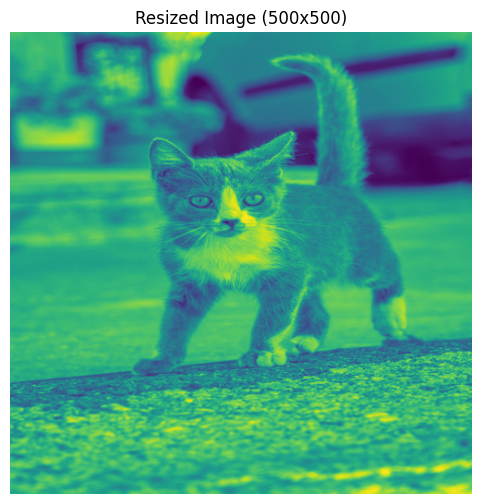

In [19]:

resized_img = image_gray.resize((500, 500))
resized_array = np.array(resized_img)

plt.figure(figsize=(6,6))
plt.imshow(resized_array)
plt.title('Resized Image (500x500)')
plt.axis('off')
plt.show()



# ==============================
# Bit Plane Slicing (RGB Image)
# ==============================


In [25]:

bit_planes = []

for i in range(8):
    plane = (image2 >> i) & 1
    bit_planes.append(plane)



# ==============================
# Reconstruct Image (Remove LSB 0 & 1)
# ==============================


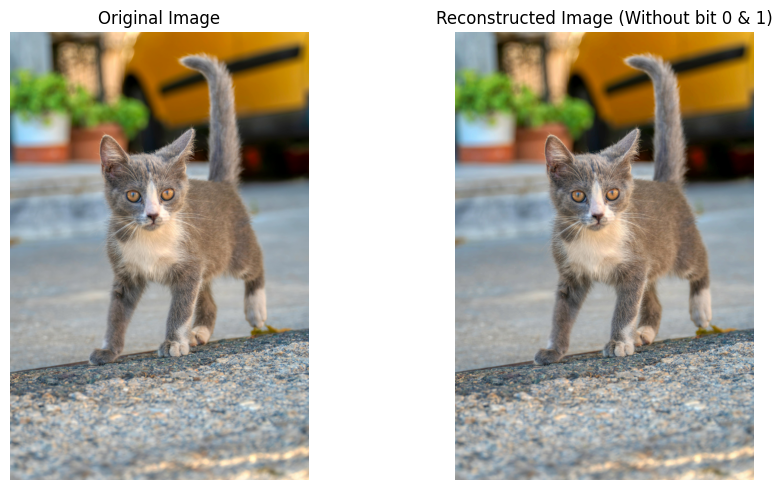

In [26]:

planes_to_keep = [i for i in range(8) if i not in [0, 1]]

reconstructed = np.zeros_like(image2, dtype=np.uint8)

for i in planes_to_keep:
    reconstructed += (bit_planes[i] << i)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image2)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed)
plt.title('Reconstructed Image (Without bit 0 & 1)')
plt.axis('off')

plt.tight_layout()
plt.show()



# ==============================
# Display All Bit Planes
# ==============================


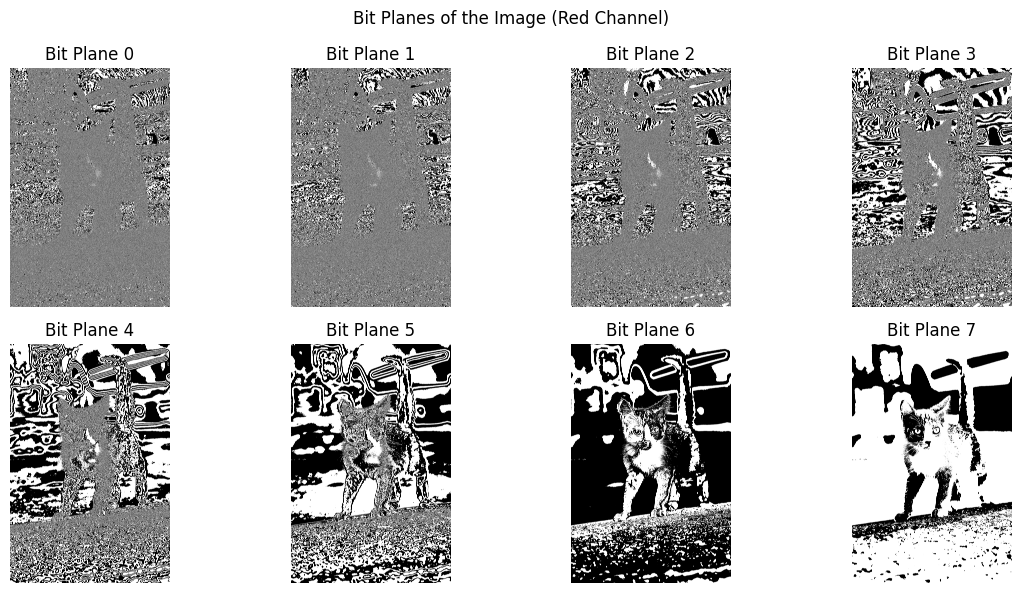

In [27]:

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.title(f'Bit Plane {i}')
    
    # Show only one channel (Red) for visualization
    plt.imshow(bit_planes[i][:,:,0], cmap='gray', vmin=0, vmax=1)
    plt.axis('off')

plt.suptitle('Bit Planes of the Image (Red Channel)')
plt.tight_layout()
plt.show()



# ==============================
# Most Significant Bit (Bit 7)
# ==============================


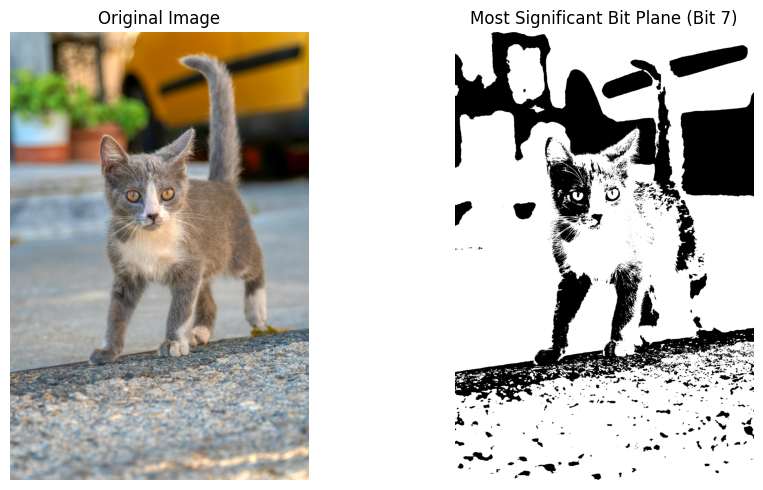

In [28]:

msb_plane = (image2 >> 7) & 1

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image2)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(msb_plane[:,:,0], cmap='gray', vmin=0, vmax=1)
plt.title('Most Significant Bit Plane (Bit 7)')
plt.axis('off')

plt.tight_layout()
plt.show()



# ==============================
# Combine Bit Planes 4,5,6,7
# ==============================


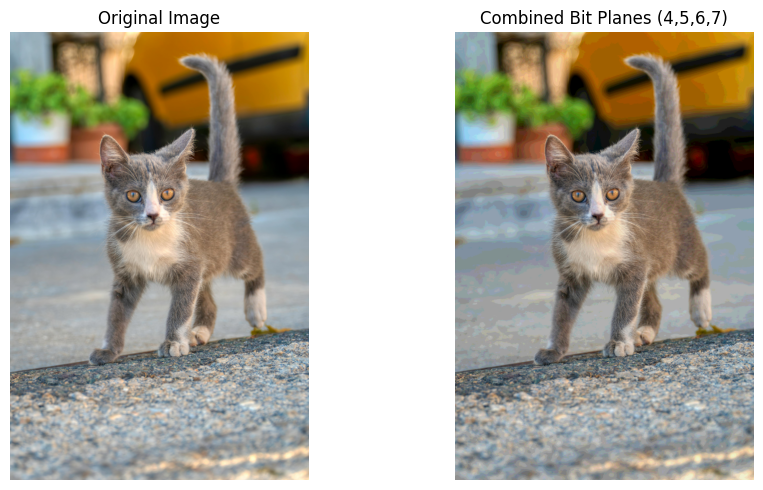

In [29]:

combined = np.zeros_like(image2, dtype=np.uint8)

for i in [4,5,6,7]:
    plane = (image2 >> i) & 1
    combined += (plane << i)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image2)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(combined)
plt.title('Combined Bit Planes (4,5,6,7)')
plt.axis('off')

plt.tight_layout()
plt.show()